# Compreensão do Cenário de Negócios e do Problema

O departamento de Recursos Humanos da **Salifort Motors** deseja implementar iniciativas para aumentar o nível de satisfação dos funcionários. Para isso, coletou diversos dados sobre seus colaboradores, mas ainda não sabe como utilizá-los de forma estratégica. Assim, a equipe recorre a um profissional de análise de dados para fornecer recomendações baseadas em evidências obtidas a partir desses dados.

A principal pergunta de negócio é:

> **Quais fatores tornam um funcionário mais propenso a deixar a empresa?**

O objetivo deste projeto é analisar os dados coletados pelo departamento de RH e desenvolver um modelo de machine learning capaz de prever se um funcionário deixará ou não a empresa.

Caso seja possível identificar antecipadamente os colaboradores com maior probabilidade de pedir demissão, a empresa poderá agir preventivamente para melhorar sua retenção. Como recrutar, entrevistar e treinar novos funcionários é um processo caro e demorado, aumentar a retenção de talentos traz benefícios tanto financeiros quanto operacionais para a organização.

# Conhecendo o Conjunto de Dados

O conjunto de dados contém **14.999 registros** e **10 variáveis**, descritas na tabela abaixo.

| Variável | Descrição |
| :--- | :--- |
| `satisfaction_level` | Nível de satisfação do funcionário, informado por ele próprio (0–1). |
| `last_evaluation` | Nota da última avaliação de desempenho do funcionário (0–1). |
| `number_project` | Número de projetos nos quais o funcionário contribui. |
| `average_monthly_hours` | Média de horas trabalhadas por mês. |
| `time_spend_company` | Tempo de permanência do funcionário na empresa (anos). |
| `Work_accident` | Indica se o funcionário sofreu um acidente de trabalho. |
| `left` | Indica se o funcionário deixou a empresa. |
| `promotion_last_5years` | Indica se o funcionário foi promovido nos últimos cinco anos. |
| `Department` | Departamento em que o funcionário trabalha. |
| `salary` | Faixa salarial do funcionário. |

# **Estágio de Planejamento**

O principal objetivo deste projeto é desenvolver um modelo preditivo para a Salifort Motors que identifique a probabilidade de um funcionário deixar a empresa. Atualmente, a empresa enfrenta uma alta taxa de rotatividade (turnover) que gera custos financeiros significativos relacionados a recrutamento e treinamento. **Sendo assim, nosso público-alvo (stakeholders) é a equipe de liderança sênior e o departamento de Recursos Humanos, que utilizarão os insights dessa análise para desenvolver estratégias práticas de retenção.**


Para realizar essa tarefa, os recursos utilizados incluem a linguagem Python e o conjunto de dados HR_capstone_dataset.csv, que contém 14.999 linhas e 10 colunas com informações autorrelatadas pelos colaboradores. A variável mais relevante e que servirá como nosso alvo (target) é a coluna left, que indica se o funcionário já saiu da empresa. Minha presunção inicial é que fatores como satisfaction_level, average_monthly_hours e number_project terão uma forte correlação com o esgotamento (burnout) e a decisão de saída, hipótese que será validada durante a Análise Exploratória de Dados (EDA).


Nesta fase de planejamento, é crucial considerar que estamos lidando com dados sensíveis de RH, exigindo responsabilidade ética na manipulação e garantia de privacidade dos funcionários. Além disso, confiamos que a amostra fornecida é aleatória e representativa de todos os setores; caso contrário, um viés de amostragem poderia comprometer a eficácia do modelo para departamentos específicos. **O produto final (deliverable) será a construção e avaliação de modelos de Regressão Logística ou outro tipo de ML, consolidados em um Sumário Executivo que traduzirá os resultados técnicos em recomendações de negócios claras.**

## #1 Importando bibliotecas

- Importando packages
- Carregando Dataset

In [21]:
# Importando packages

# Manipulação de dados
import numpy as np
import pandas as pd

# Visualização de dados
import matplotlib.pyplot as plt
import seaborn as sns

# Configurações de visualização
pd.set_option('display.max_columns', None)

# Modelos de machine learning

from xgboost import XGBClassifier
from xgboost import XGBRegressor
from xgboost import plot_importance

from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier

# Métricas e funções
from sklearn.model_selection import GridSearchCV, train_test_split
from sklearn.metrics import accuracy_score, precision_score, recall_score,f1_score, confusion_matrix, ConfusionMatrixDisplay, classification_report
from sklearn.metrics import roc_auc_score, roc_curve
from sklearn.tree import plot_tree

# Salvar modelos
import pickle

In [22]:
%cd salifort-motors-retention-analysis/

### Carregando dados

In [23]:
df0 = pd.read_csv("data/HR_comma_sep.csv")

In [24]:
df0.head()

,satisfaction_level,last_evaluation,number_project,average_montly_hours,time_spend_company,Work_accident,left,promotion_last_5years,Department,salary
0,0.38,0.53,2,157,3,0,1,0,sales,low
1,0.80,0.86,5,262,6,0,1,0,sales,medium
2,0.11,0.88,7,272,4,0,1,0,sales,medium
3,0.72,0.87,5,223,5,0,1,0,sales,low
4,0.37,0.52,2,159,3,0,1,0,sales,low


## #2. Análise Exploratória (EDA e limpeza de dados)

- Entendendo as variáveis
- Limpando dataset (valores nulos, data redundante, outliers...)

### Obtendo informação básica sobre os dados:

In [25]:
df0.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 14999 entries, 0 to 14998
Data columns (total 10 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   satisfaction_level     14999 non-null  float64
 1   last_evaluation        14999 non-null  float64
 2   number_project         14999 non-null  int64  
 3   average_montly_hours   14999 non-null  int64  
 4   time_spend_company     14999 non-null  int64  
 5   Work_accident          14999 non-null  int64  
 6   left                   14999 non-null  int64  
 7   promotion_last_5years  14999 non-null  int64  
 8   Department             14999 non-null  object 
 9   salary                 14999 non-null  object 
dtypes: float64(2), int64(6), object(2)
memory usage: 1.1+ MB


### Obtendo estatística descritiva básica:

In [26]:
df0.describe()

,satisfaction_level,last_evaluation,number_project,average_montly_hours,time_spend_company,Work_accident,left,promotion_last_5years
count,14999.000000,14999.000000,14999.000000,14999.000000,14999.000000,14999.000000,14999.000000,14999.000000
mean,0.612834,0.716102,3.803054,201.050337,3.498233,0.144610,0.238083,0.021268
std,0.248631,0.171169,1.232592,49.943099,1.460136,0.351719,0.425924,0.144281
min,0.090000,0.360000,2.000000,96.000000,2.000000,0.000000,0.000000,0.000000
25%,0.440000,0.560000,3.000000,156.000000,3.000000,0.000000,0.000000,0.000000
50%,0.640000,0.720000,4.000000,200.000000,3.000000,0.000000,0.000000,0.000000
75%,0.820000,0.870000,5.000000,245.000000,4.000000,0.000000,0.000000,0.000000
max,1.000000,1.000000,7.000000,310.000000,10.000000,1.000000,1.000000,1.000000


### Renomeando colunas

Padronizando para que todas fiquem em formato snake_case, corrigindo erros ortográficos e deixando os nomes mais concisos possível.

In [27]:
df0.columns

Index(['satisfaction_level', 'last_evaluation', 'number_project',
       'average_montly_hours', 'time_spend_company', 'Work_accident', 'left',
       'promotion_last_5years', 'Department', 'salary'],
      dtype='object')

In [28]:
df0 = df0.rename(columns = {
                          'Work_accident': 'work_accident',
                          'average_montly_hours': 'average_monthly_hours',
                          'time_spend_company': 'tenure',
                          'Department': 'department'
                          })

df0.columns

Index(['satisfaction_level', 'last_evaluation', 'number_project',
       'average_monthly_hours', 'tenure', 'work_accident', 'left',
       'promotion_last_5years', 'department', 'salary'],
      dtype='object')

### Buscando valores nulos

In [29]:
df0.isna().sum()

,0
satisfaction_level,0
last_evaluation,0
number_project,0
average_monthly_hours,0
tenure,0
work_accident,0
left,0
promotion_last_5years,0
department,0
salary,0


O dado não contém valores nulos, em nenhuma das variáveis.

### Buscando duplicados

In [30]:
df0.duplicated().sum()

np.int64(3008)

Aqui, encontramos que 3008 valores são duplicados, o que representa 20% dos dados.

In [31]:
df0[df0.duplicated()].head()

,satisfaction_level,last_evaluation,number_project,average_monthly_hours,tenure,work_accident,left,promotion_last_5years,department,salary
396,0.46,0.57,2,139,3,0,1,0,sales,low
866,0.41,0.46,2,128,3,0,1,0,accounting,low
1317,0.37,0.51,2,127,3,0,1,0,sales,medium
1368,0.41,0.52,2,132,3,0,1,0,RandD,low
1461,0.42,0.53,2,142,3,0,1,0,sales,low


A célula acima mostra cinco ocorrências de células duplicadas no conjunto de dados.

**Isso se mostra ser um problema porquê é improvável que tantos funcionários assim tenham exatamente os mesmos valores, principalmente quando os níveis de satisfação e o last_evaluation podem chegar em até 100 valores diferentes.**

Um teorema de Bayes poderua ser aplicado para medir a probabilidade disso ser um erro, mas por fins práticos para esse exercício de análise, vamos desconsiderar esses valores para a nossa análise e eventual criação de modelos.

In [32]:
df1 = df0.drop_duplicates(keep = 'first')

df1.head()

,satisfaction_level,last_evaluation,number_project,average_monthly_hours,tenure,work_accident,left,promotion_last_5years,department,salary
0,0.38,0.53,2,157,3,0,1,0,sales,low
1,0.80,0.86,5,262,6,0,1,0,sales,medium
2,0.11,0.88,7,272,4,0,1,0,sales,medium
3,0.72,0.87,5,223,5,0,1,0,sales,low
4,0.37,0.52,2,159,3,0,1,0,sales,low


### Buscando outliers (valores fora do comum)

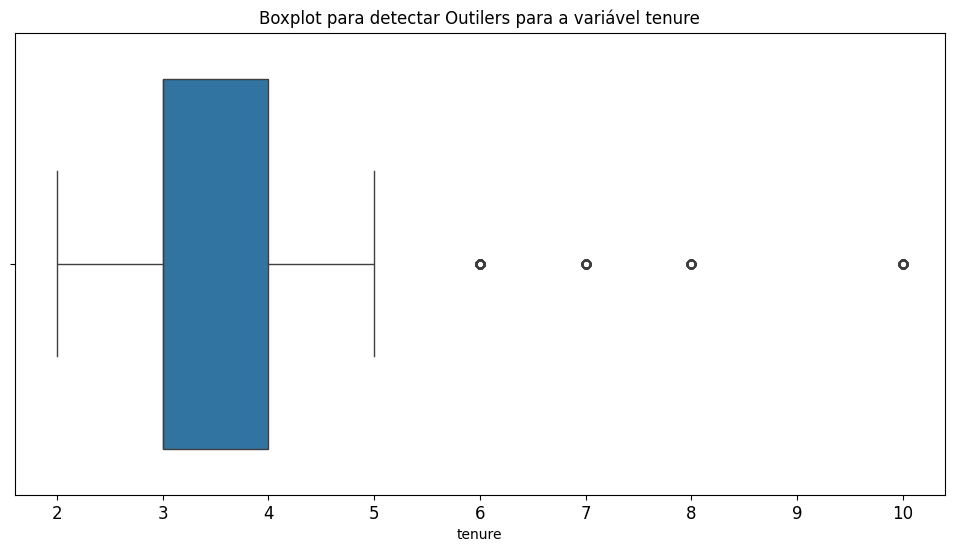

In [33]:
plt.figure(figsize = (12, 6))
plt.title('Boxplot para detectar Outilers para a variável tenure', fontsize = 12)
plt.xticks(fontsize = 12)
plt.yticks(fontsize = 12)
sns.boxplot(x = df1['tenure'])
plt.show()

O Boxplot acima foi criado para a variável 'tenure', que representa o tempo que o funcionário passou na empresa. **No geral, os valores tendem a ir de 2 a 5 anos, com alguns valores fora do comum de funcionários que passaram até 10 anos na empresa.**

Agora, investigando a quantidade de outliers nos dados usando quartis:

In [34]:
percentile25 = df1['tenure'].quantile(0.25)

percentile75 = df1['tenure'].quantile(0.75)

iqr = percentile75 - percentile25

upper_limit = percentile75 + 1.5 * iqr
lower_limit = percentile25 - 1.5 * iqr
print("Limite inferior:", lower_limit)
print("Limite superior:", upper_limit)

outliers = df1[(df1['tenure'] > upper_limit) | (df1['tenure'] < lower_limit)]

print("Quantidade de outliers em 'tenure':", len(outliers))

Limite inferior: 1.5
Limite superior: 5.5
Quantidade de outliers em 'tenure': 824


# **Estágio de Análise**

**Nesta fase de Análise, o foco principal é realizar uma Análise Exploratória de Dados (EDA) rigorosa para confirmar se as informações disponíveis são suficientes para atingir nosso objetivo preditivo**. As estatísticas descritivas são fundamentais aqui para entendermos a distribuição inicial dos dados, identificando médias e identificando possíveis outliers (como extremos em horas trabalhadas ou níveis de satisfação muito baixos). A estruturação inicial do conjunto de dados envolverá a renomeação de colunas para padronização, a verificação de valores nulos e a remoção de linhas duplicadas para garantir a integridade das informações antes da modelagem.


Para traduzir esses dados em insights compreensíveis para a liderança, a aposta será em visualizações claras e diretas. Utilizaremos heatmaps para identificar a correlação entre as variáveis independentes e a variável alvo left, além de gráficos de barras e boxplots para comparar a taxa de rotatividade entre diferentes departamentos e níveis salariais. Esses passos da EDA são cruciais antes de construir os modelos, pois permitem verificar premissas matemáticas importantes, como a ausência de alta multicolinearidade — um requisito essencial caso optemos por avançar com a Regressão Logística.


Por fim, a seleção das variáveis preditoras será baseada diretamente no que a EDA nos revelar sobre sua influência na saída dos funcionários. **Durante todo esse processo de exploração e limpeza estrutural, manteremos considerações éticas em mente, garantindo que as conclusões tiradas não reforcem vieses injustos e que os dados autorrelatados continuem descaracterizados para proteger a privacidade dos colaboradores**. Confirmada a confiabilidade dos dados e validadas as premissas, o plano original de seguir com a construção dos modelos de Machine Learning e estatística se mantém sólido.


## Continuação da Exploração de Dados

Compreendendo a quantidade e a proporção de funcionários que permaneceram / abondonaram no dataset.

In [36]:
print(df1['left'].value_counts())
print()

print(df1['left'].value_counts(normalize=True))

left
0    10000
1     1991
Name: count, dtype: int64

left
0    0.833959
1    0.166041
Name: proportion, dtype: float64


Isso revela que 83% (10.000) funcionários ficaram na empresa nos valores do dataset, enquanto o resto deixou.

## Visualizações de Dados

**Faz sentido criar um gráfico com mútiplos boxplots para entender a forma que o status de abondono ou permanência na empresa varia baseado em horas médias mensais e número de projetos que o funcionario esteve envolvido**. A escolha do boxplot veio do fato que ele é bom em representar o tamanho das amostras.

**Também faremos um histograma para visualizar a dsitribuição de funcionários que abondonaram / ficaram baseado na quantidade de projetos que trabalharam.**

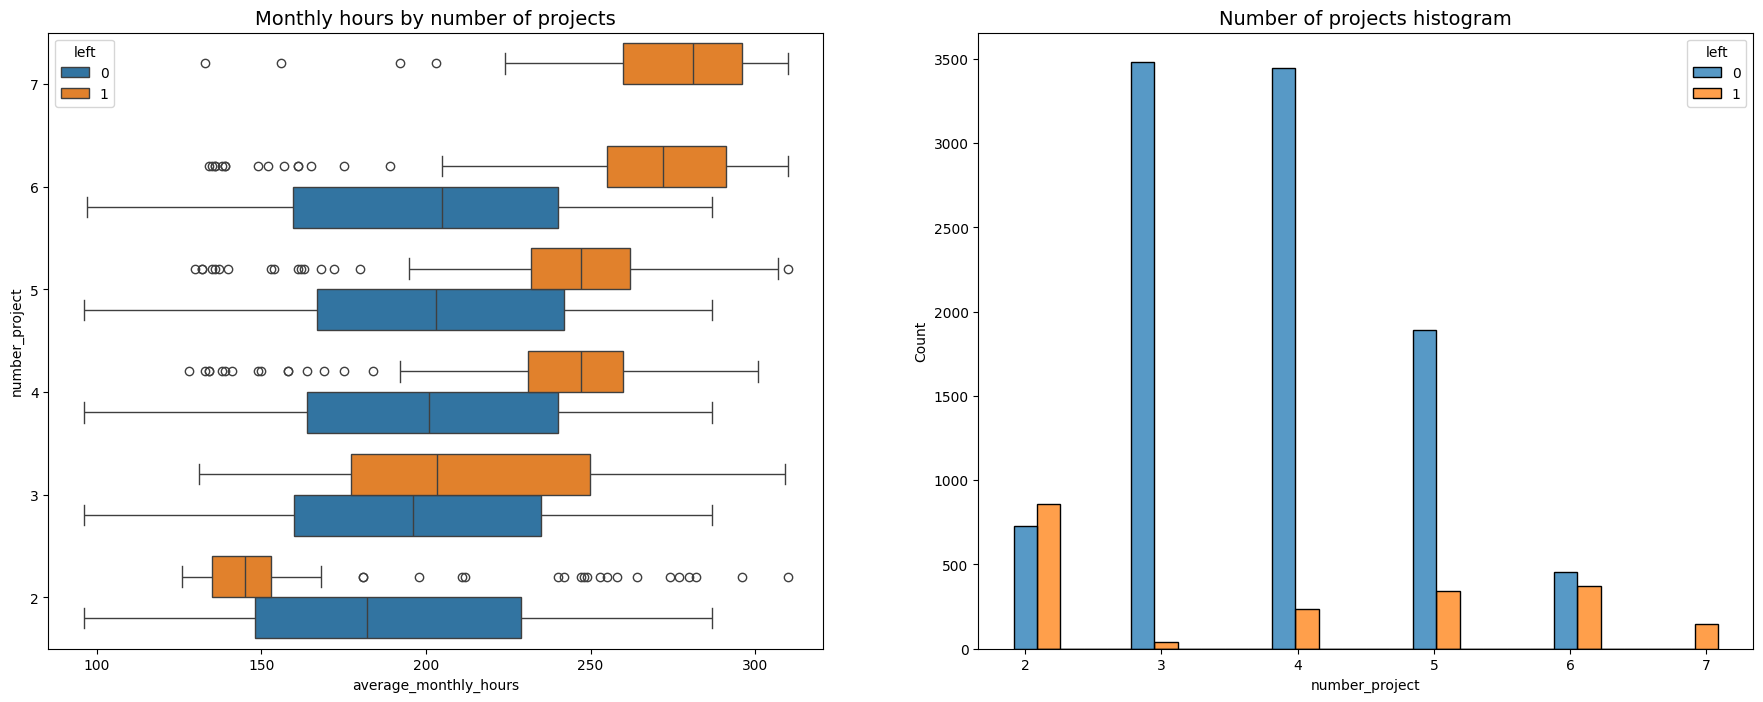

In [35]:
fig, ax = plt.subplots(1, 2, figsize = (22,8))

sns.boxplot(data=df1, x='average_monthly_hours', y='number_project', hue='left', orient="h", ax=ax[0])
ax[0].invert_yaxis()
ax[0].set_title('Monthly hours by number of projects', fontsize='14')

tenure_stay = df1[df1['left']==0]['number_project']
tenure_left = df1[df1['left']==1]['number_project']
sns.histplot(data=df1, x='number_project', hue='left', multiple='dodge', shrink=2, ax=ax[1])
ax[1].set_title('Number of projects histogram', fontsize='14')

plt.show()

É possível observar uma relação positiva entre o número de projetos e a quantidade de horas trabalhadas: quanto mais projetos um funcionário assume, maior tende a ser sua carga horária mensal.

Entre os funcionários que deixaram a empresa, destacam-se dois perfis: aqueles que trabalharam significativamente menos horas que seus colegas com a mesma quantidade de projetos, possivelmente por demissão, desligamento já comunicado ou insatisfação com a baixa demanda de trabalho; e aqueles que trabalharam muito mais horas, indicando um possível cenário de sobrecarga que pode ter contribuído para o pedido de demissão.

Outro ponto relevante é que **todos os funcionários que participaram de sete projetos deixaram a empresa**, enquanto aqueles envolvidos em **três ou quatro projetos apresentaram a menor taxa de desligamento**, sugerindo que essa pode ser a faixa mais equilibrada de alocação.

Além disso, considerando uma jornada padrão de aproximadamente **166 horas mensais**, observa-se que praticamente todos os grupos, inclusive os que permaneceram na empresa, trabalharam acima desse valor. Isso indica um possível cenário generalizado de excesso de carga de trabalho.

Como próximo passo, vale confirmar se todos os funcionários com sete projetos realmente deixaram a empresa e investigar mais profundamente o impacto da quantidade de projetos e da carga horária sobre a rotatividade.


In [37]:
df1[df1['number_project']==7]['left'].value_counts()

,count
left,
1,145


Isso confirma que todos os funcionários com 7 projetos, defato, saíram.

Agora, examinaremos como as horas mensais médias se comparam com o nível de satisfação.

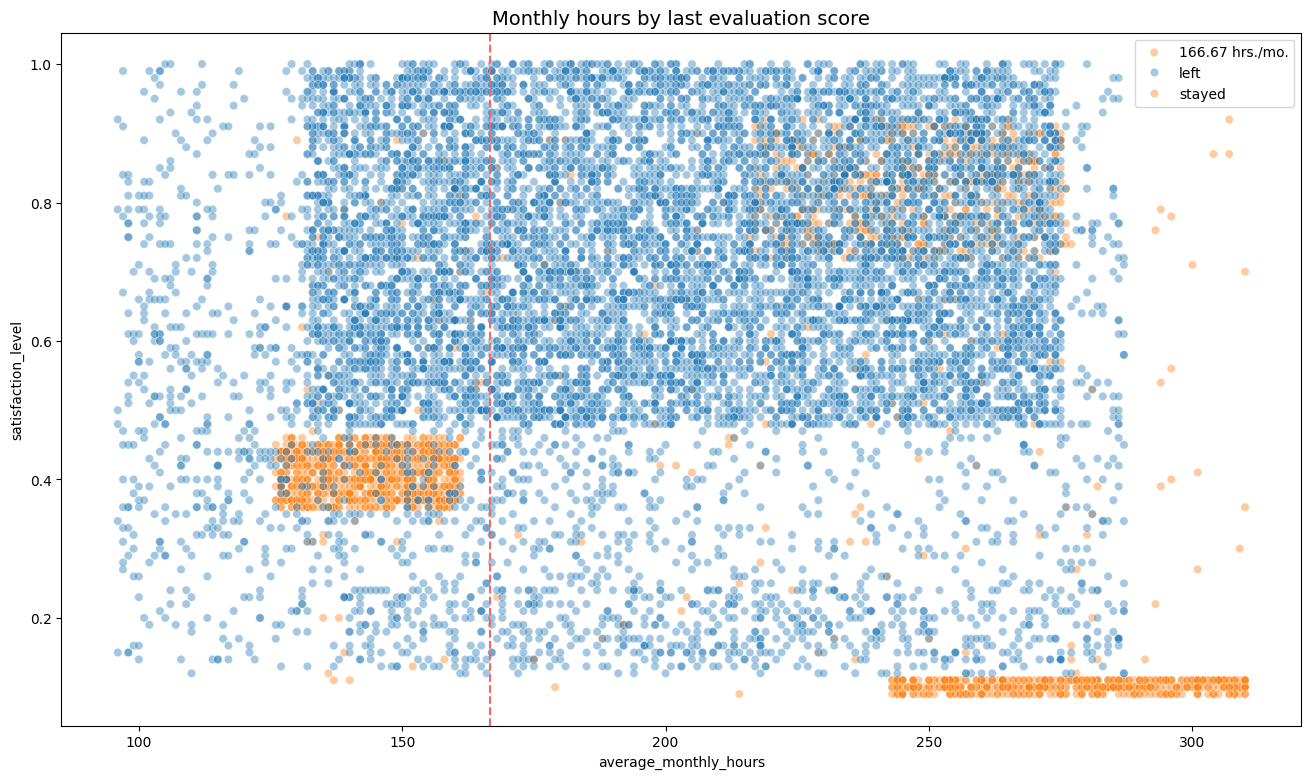

In [38]:
plt.figure(figsize=(16, 9))
sns.scatterplot(data=df1, x='average_monthly_hours', y='satisfaction_level', hue='left', alpha=0.4)
plt.axvline(x=166.67, color='#ff6361', label='166.67 hrs./mo.', ls='--')
plt.legend(labels=['166.67 hrs./mo.', 'left', 'stayed'])
plt.title('Monthly hours by last evaluation score', fontsize='14');

O gráfico de dispersão acima mostra que havia um grupo significativo de funcionários que trabalhava aproximadamente **240 a 315 horas por mês**. Uma carga de **315 horas mensais** equivale a mais de **75 horas por semana** ao longo de um ano, o que pode explicar os níveis de satisfação próximos de zero observados nesse grupo.

O gráfico também revela outro grupo de funcionários que deixou a empresa apesar de trabalhar uma carga horária mais próxima do normal. Ainda assim, seus níveis de satisfação estavam em torno de **0,4**. É difícil afirmar o motivo de seus desligamentos, mas uma hipótese é que esses funcionários se sentissem pressionados a trabalhar mais ao observar a carga de trabalho de muitos de seus colegas, o que pode ter reduzido sua satisfação.

Por fim, existe um terceiro grupo que trabalhava entre **210 e 280 horas por mês** e apresentava níveis de satisfação relativamente altos, variando aproximadamente entre **0,7 e 0,9**.

Vale destacar o formato incomum das distribuições observadas nesse gráfico. Esse padrão pode indicar que os dados foram manipulados ou que se tratam de dados sintéticos.


Agora, verificaremos o nível de satisfação por tempo na empresa, também baseado em se os profissionais ficaram ou foram embora.

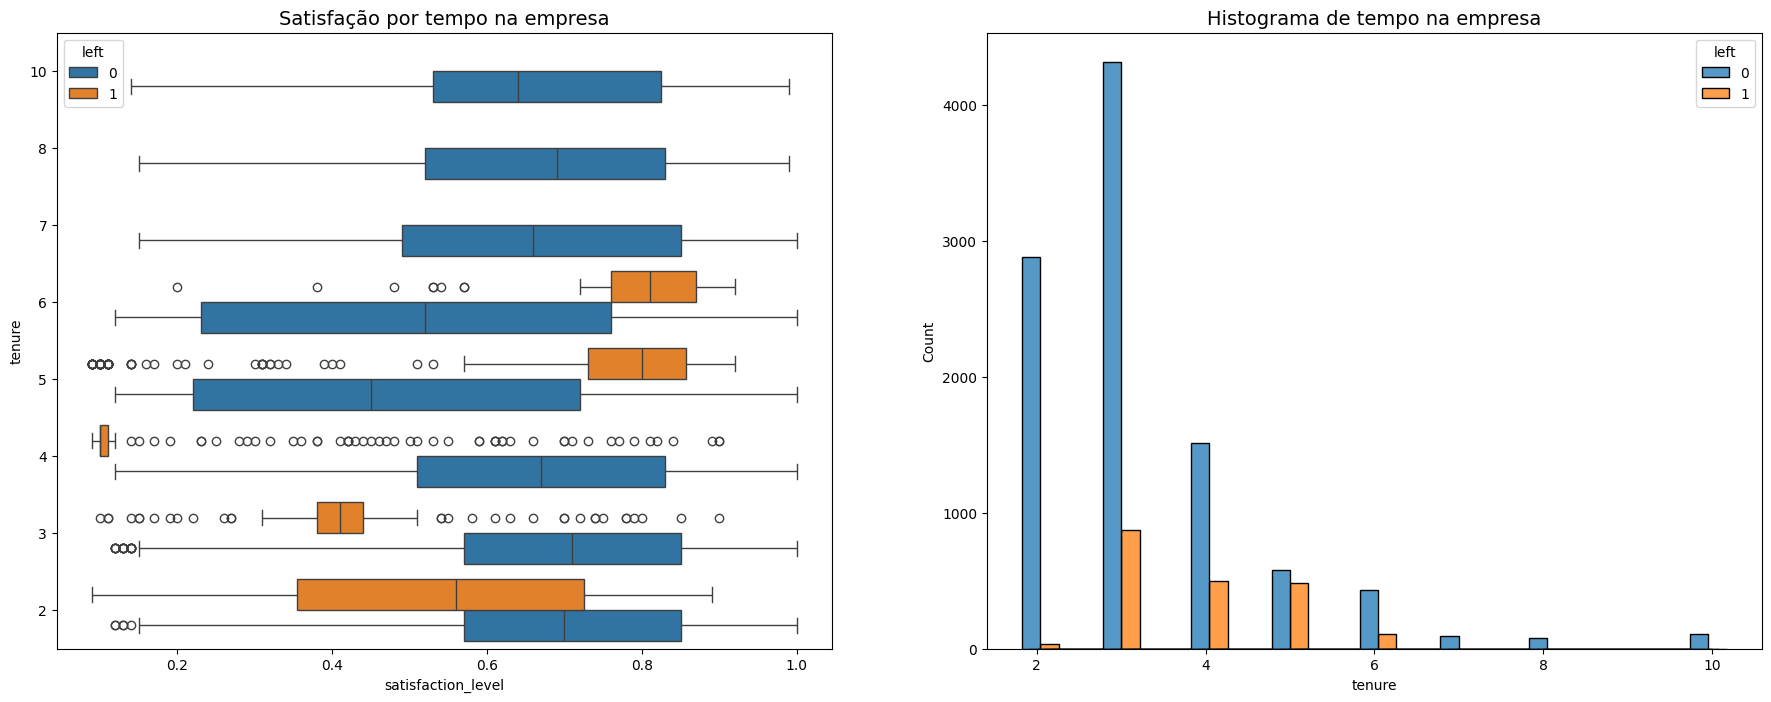

In [39]:
fig, ax = plt.subplots(1, 2, figsize = (22,8))

sns.boxplot(data=df1, x='satisfaction_level', y='tenure', hue='left', orient="h", ax=ax[0])
ax[0].invert_yaxis()
ax[0].set_title('Satisfação por tempo na empresa', fontsize='14')

tenure_stay = df1[df1['left']==0]['tenure']
tenure_left = df1[df1['left']==1]['tenure']
sns.histplot(data=df1, x='tenure', hue='left', multiple='dodge', shrink=5, ax=ax[1])
ax[1].set_title('Histograma de tempo na empresa', fontsize='14')

plt.show();

Há algumas observações que podem ser feitas a partir dos gráficos:

Os funcionários que **deixaram** a empresa podem ser agrupados em dois perfis principais: **funcionários insatisfeitos com pouco tempo de empresa** e **funcionários muito satisfeitos com tempo de empresa intermediário**.

Os funcionários que deixaram a empresa após **quatro anos** apresentaram um nível de satisfação excepcionalmente baixo. Vale a pena investigar se houve alguma mudança nas políticas da empresa que tenha afetado especificamente os colaboradores nesse período de permanência.

Os funcionários com **maior tempo de empresa** permaneceram na organização. Seus níveis de satisfação são semelhantes aos dos funcionários mais novos que também permaneceram. O histograma mostra que há relativamente poucos funcionários com longos períodos de permanência na empresa. É possível que esse grupo seja composto por colaboradores em cargos mais altos e com salários mais elevados.

Como próximo passo da análise, seria interessante calcular a **média** e a **mediana** dos níveis de satisfação dos funcionários que permaneceram na empresa e daqueles que a deixaram.


In [54]:
df1.groupby('left')['satisfaction_level'].agg(['mean', 'median'])

,mean,median
left,,
0,0.667365,0.69
1,0.440271,0.41


Previsivelmente, os fucionários que deixaram constavam com níveis de satisfação mais baixos. Agora, analisaremos com histogramas a relação dos salários com o tempo de permanência na empresa.

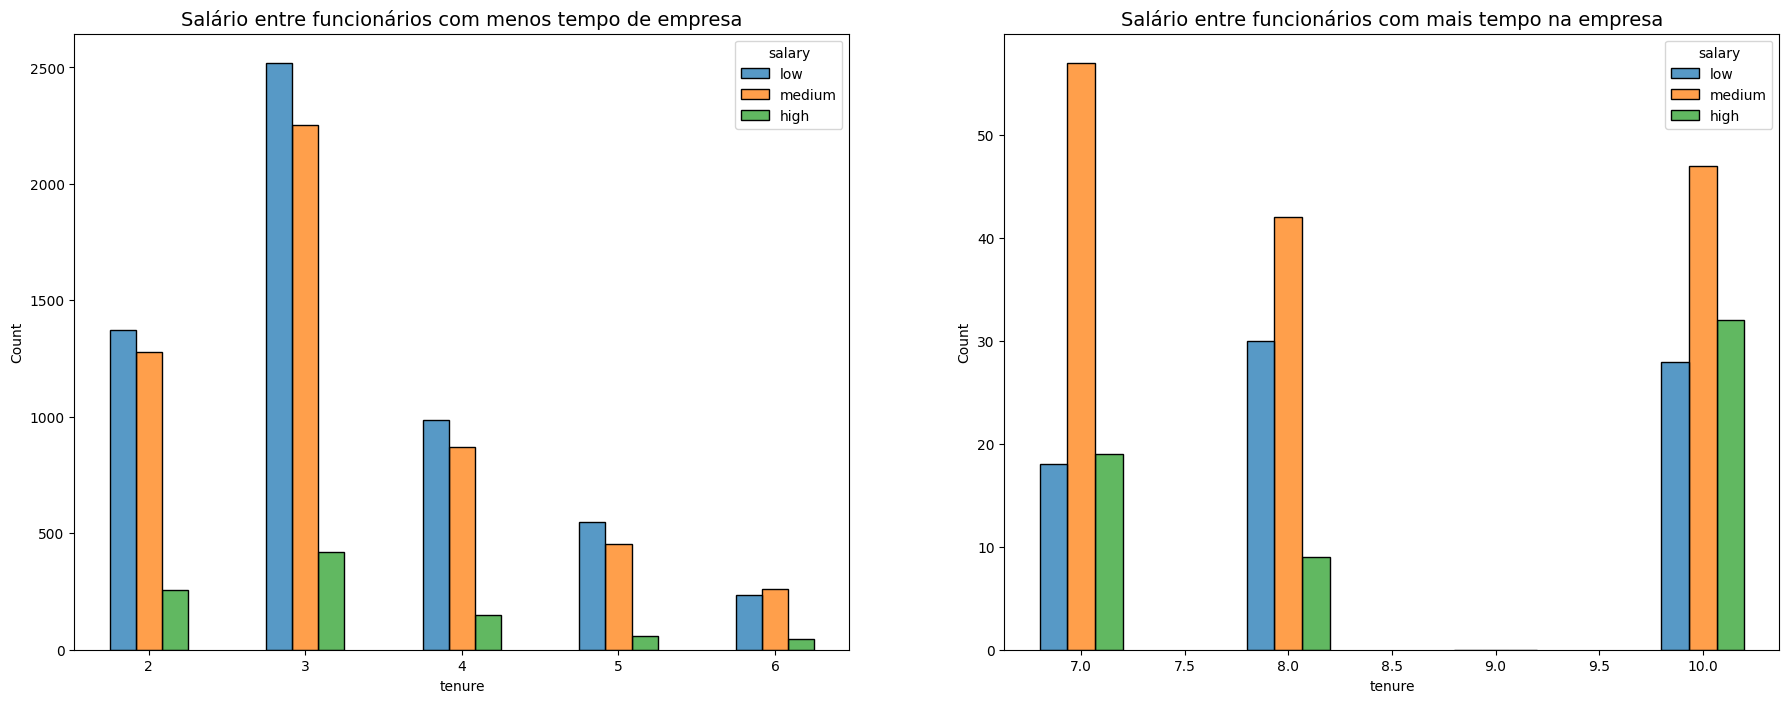

In [41]:
fig, ax = plt.subplots(1, 2, figsize = (22,8))

tenure_short = df1[df1['tenure'] < 7]

tenure_long = df1[df1['tenure'] > 6]

sns.histplot(data=tenure_short, x='tenure', hue='salary', discrete=1, hue_order=['low', 'medium', 'high'], multiple='dodge', shrink=.5, ax=ax[0])
ax[0].set_title('Salário entre funcionários com menos tempo de empresa', fontsize='14')

sns.histplot(data=tenure_long, x='tenure', hue='salary', discrete=1, hue_order=['low', 'medium', 'high'], multiple='dodge', shrink=.4, ax=ax[1])
ax[1].set_title('Salário entre funcionários com mais tempo na empresa', fontsize='14');

Os gráficos acima mostram que os funcionários com **maior tempo de empresa** não são, de forma desproporcional, aqueles que recebem os **maiores salários**.

Como próximo passo da análise, vale investigar se existe uma relação entre longas jornadas de trabalho e altas avaliações de desempenho. Para isso, pode ser criado um gráfico de dispersão (scatterplot) comparando as variáveis average_monthly_hours (média de horas trabalhadas por mês) e last_evaluation (nota da última avaliação de desempenho).


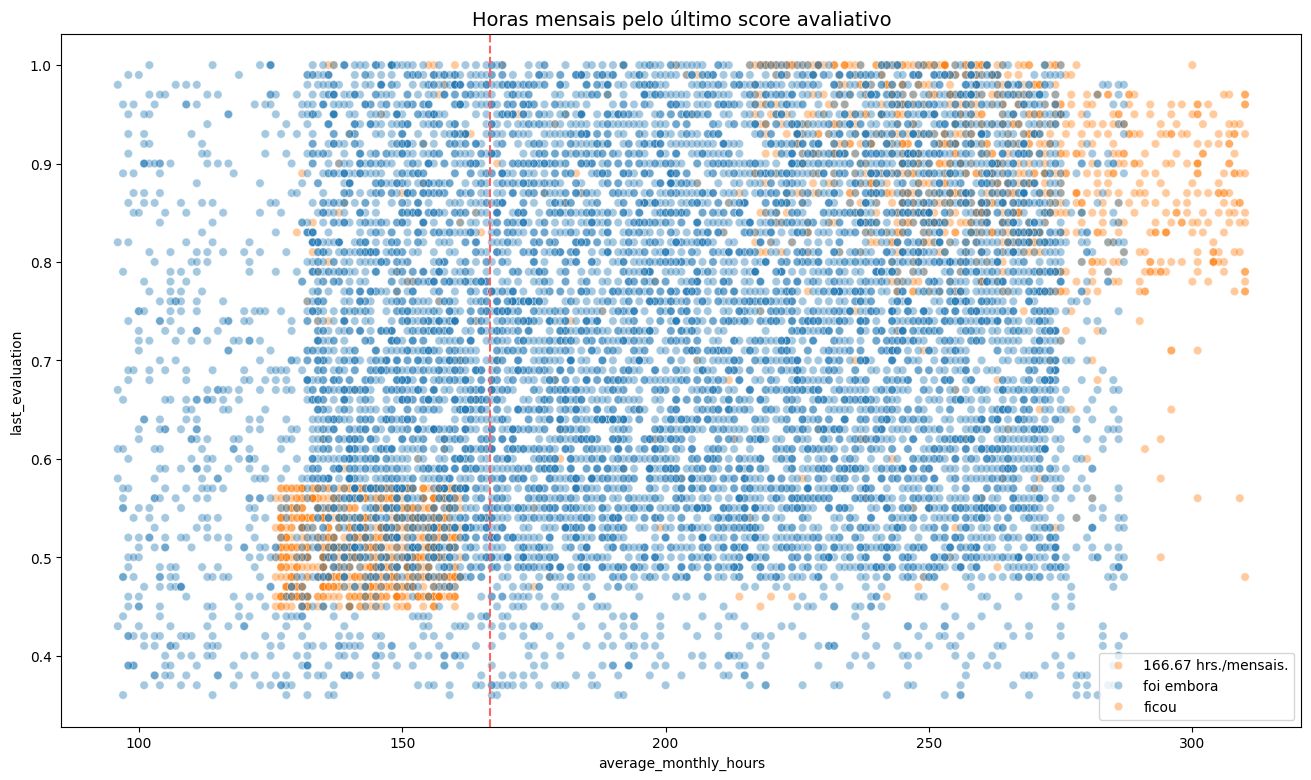

In [44]:
plt.figure(figsize=(16, 9))
sns.scatterplot(data=df1, x='average_monthly_hours', y='last_evaluation', hue='left', alpha=0.4)
plt.axvline(x=166.67, color='#ff6361', label='166.67 hrs./mensais.', ls='--')
plt.legend(labels=['166.67 hrs./mensais.', 'foi embora', 'ficou'])
plt.title('Horas mensais pelo último score avaliativo', fontsize='14');

A partir do gráfico de dispersão, é possível destacar as observações:

- Os funcionários que deixaram a empresa parecem se concentrar em dois perfis: **colaboradores com alto desempenho e carga de trabalho excessiva** e **colaboradores com menor carga horária (próxima da média mensal de 166,7 horas) e avaliações de desempenho mais baixas**.

- Observa-se uma **tendência de correlação positiva** entre a quantidade de horas trabalhadas e a nota da última avaliação de desempenho, mesmo que não de forma tão concreta.

- Trabalhar muitas horas não garante uma avaliação elevada. Grandeparte dos funcionários com cargas horárias muito altas não recebem boas avaliações

- Além disso, a maioria dos funcionários da empresa trabalha **bem acima de 166 horas por mês**, reforçando a hipótese de uma carga de trabalho elevada na organização.

Como próximo passo da análise, seria interessante investigar se os funcionários que trabalharam jornadas muito longas **receberam promoções nos últimos cinco anos**.


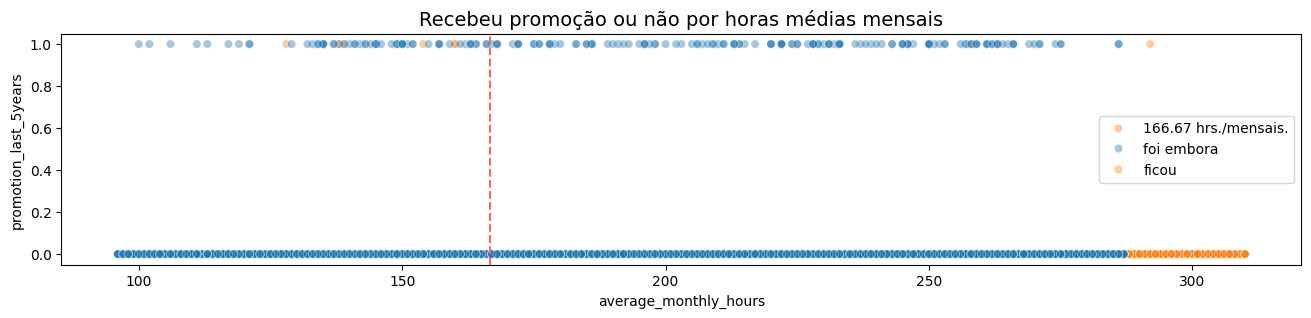

In [46]:
plt.figure(figsize=(16, 3))
sns.scatterplot(data=df1, x='average_monthly_hours', y='promotion_last_5years', hue='left', alpha=0.4)
plt.axvline(x=166.67, color='#ff6361', ls='--')
plt.legend(labels=['166.67 hrs./mensais.', 'foi embora', 'ficou'])
plt.title('Recebeu promoção ou não por horas médias mensais', fontsize='14');

O plot revela que muitos poucos funcionários receberam promoções nos últimos 5 anos, e que a diferença por hora não foi significante.

Agora, analisaremos como os funcionários que deixaram estão distribuídos por departamento.

In [47]:
df1['department'].value_counts()

,count
department,
sales,3239
technical,2244
support,1821
IT,976
RandD,694
product_mng,686
marketing,673
accounting,621
hr,601


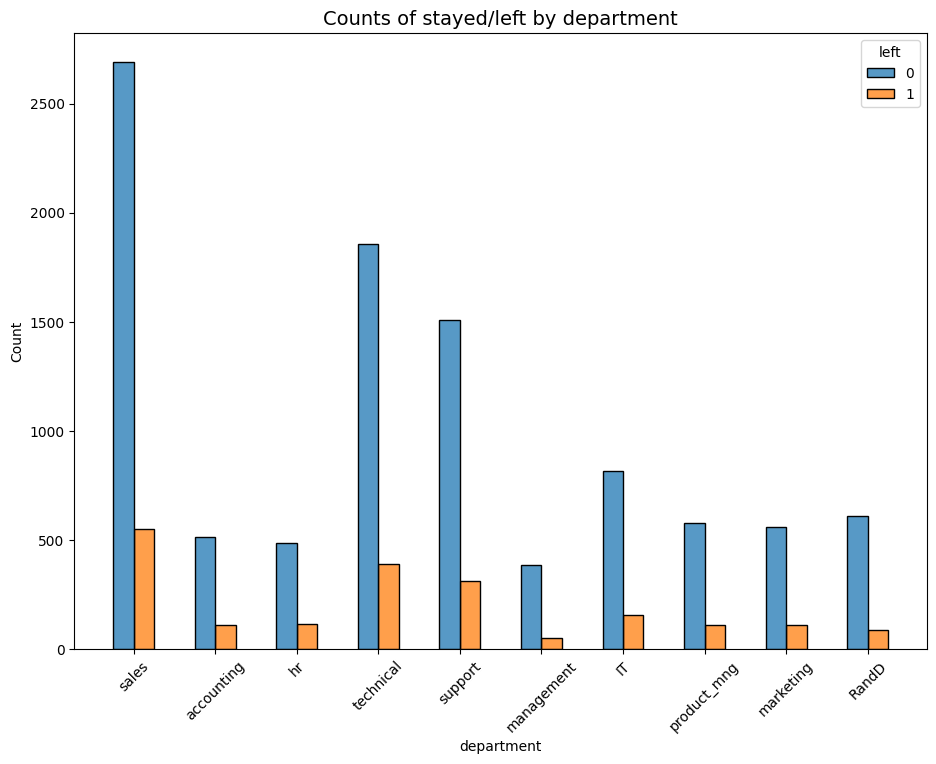

In [49]:
plt.figure(figsize=(11,8))
sns.histplot(data=df1, x='department', hue='left', discrete=1, hue_order=[0, 1], multiple='dodge', shrink=.5)
plt.xticks(rotation= 45)
plt.title('Counts of stayed/left by department', fontsize=14);


In [50]:
df1.groupby('department')['left'].mean()

,left
department,
IT,0.161885
RandD,0.122478
accounting,0.175523
hr,0.188020
management,0.119266
marketing,0.166419
product_mng,0.160350
sales,0.169805
support,0.171334


Não parece haver uma proporção significantemente diferente de grupo para grupo, a parte de manageament parece ter retido um pouco mais de funcionários apenas mas pode ser um acaso. Poderíamos fazer um teste de hipótese mas por agora seguiremos com a análise sem isso.

Por último, verificaremos correlações fortes entre os dados com um heatmap.

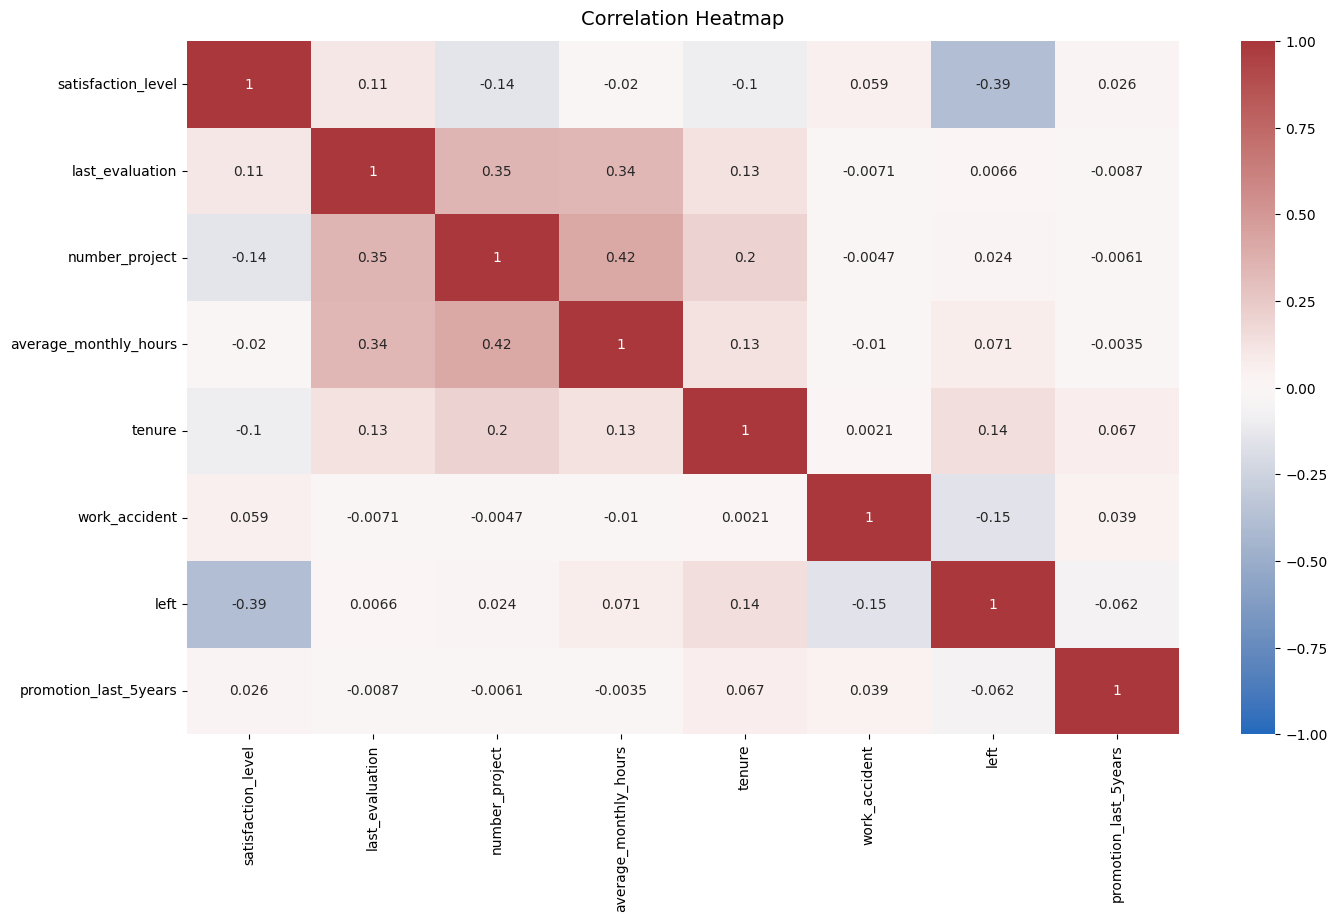

In [53]:
plt.figure(figsize=(16, 9))
heatmap = sns.heatmap(df0.corr(numeric_only = True), vmin = -1, vmax = 1, annot = True, cmap = sns.color_palette("vlag", as_cmap=True))
heatmap.set_title('Correlation Heatmap', fontdict={'fontsize':14}, pad=12);

O mapa de correlação mostra que existe uma certa correlação positiva de números de projetos, horas mensais médias e quantidade de projetos por funcionário, mas parece existir uma correlação negativa entre funcionários que deixaram a empresa e seu nível de satisfação.

## O que extraímos da Análise Exploratória?

Os resultados da análise sugerem que os desligamentos de funcionários estão associados a questões de gestão. A saída da empresa está relacionada a **jornadas de trabalho mais longas**, **maior número de projetos** e, de forma geral, **menores níveis de satisfação**.

Trabalhar por muitas horas sem receber promoções ou avaliações de desempenho que reflitam esse esforço pode ser desmotivador. Os dados indicam a existência de um grupo significativo de funcionários que provavelmente apresenta sinais de burnout.

Além disso, observa-se que funcionários com **mais de seis anos de empresa** tendem a permanecer na organização, apresentando uma probabilidade menor de desligamento.


# **Estágio de Construção**

**Para atingir os objetivos preditivos do projeto, esta fase foca na engenharia de recursos e na construção dos modelos de Machine Learning e estatística, especificamente Regressão Logística, Árvore e Random Forest**. O processo de preparação exige a codificação de variáveis categóricas (como department e salary) em formato numérico (variáveis dummy) e o tratamento de anomalias descobertas na fase de análise, como valores extremos de horas trabalhadas ou inconsistências em avaliações. As variáveis independentes (X) escolhidas para alimentar os modelos englobarão os atributos que demonstraram maior poder preditivo na EDA, como o nível de satisfação (satisfaction_level), a carga de trabalho (average_monthly_hours) e o número de projetos (number_project).

**A validação de como o modelo se ajusta aos dados não se baseará apenas na acurácia global, mas principalmente em métricas mais sensíveis ao desbalanceamento de classes, como Precision, Recall, F1-score e a curva ROC-AUC**. Caso as métricas iniciais de validação revelem um ajuste insatisfatório (como overfitting nas árvores de decisão), o modelo será aprimorado através do ajuste de hiperparâmetros (usando técnicas como GridSearchCV). Além disso, visualizações como matrizes de confusão e gráficos de importância de recursos (feature importance) serão geradas para interpretar como o modelo toma suas decisões.

**Do ponto de vista ético, o principal cuidado nesta etapa é garantir que o algoritmo não desenvolva vieses discriminatórios**. Precisamos observar se o modelo penaliza injustamente ou prevê taxas de evasão distorcidas para grupos salariais mais baixos ou departamentos específicos de forma não justificada. O objetivo da construção desse modelo é ajudar a empresa a intervir positivamente e melhorar a cultura do ambiente de trabalho, e não criar uma ferramenta de monitoramento punitiva.


# **Estágio de Execução:**

**Nesta etapa final, traduzimos o desempenho técnico dos modelos em recomendações de negócios estratégicas para a equipe de liderança**. A avaliação dos modelos demonstrou que algoritmos baseados em árvores (Random Forest ou XGBoost) superam a Regressão Logística em capacidade preditiva geral. No entanto, a análise estatística inicial da Regressão Logística provou ser valiosa: ao interpretar os coeficientes beta, pudemos entender a direção exata e a magnitude do impacto de cada variável. **Os principais insights indicam que o excesso de trabalho (altos valores em average_monthly_hours e number_project) associado a baixos níveis de satisfação (satisfaction_level) são os maiores impulsionadores da rotatividade. Funcionários sobrecarregados estão esgotados, enquanto aqueles com pouquíssimos projetos também saem, possivelmente por desmotivação.**

Com base nesses resultados, a principal recomendação de negócios para aumentar a retenção é limitar a quantidade simultânea de projetos por funcionário e monitorar de perto a carga horária mensal, evitando o burnout. Além disso, a empresa deve revisar sua estrutura de incentivos e promoções, já que a ausência de progressão na carreira também afeta negativamente a permanência. Para compartilhar essas informações de forma eficaz, os gráficos de importância de recursos (feature importance) e a matriz de confusão serão simplificados e incluídos no Sumário Executivo, garantindo que públicos não técnicos consigam compreender claramente as causas do problema e o valor do modelo preditivo.

**Do ponto de vista ético e de implementação, é essencial entender o impacto das falhas do modelo. Quando o algoritmo comete um erro (como um Falso Positivo), a empresa pode acabar direcionando esforços de retenção para um funcionário que não pretendia sair; por outro lado (Falso Negativo), a empresa pode perder um talento que o modelo julgou estar seguro**. Eticamente, os resultados deste modelo devem ser usados de forma proativa para apoiar os colaboradores e melhorar a cultura da empresa, e não como uma ferramenta de vigilância ou base para demissões preventivas. No futuro, para fortalecer ainda mais esse modelo, a equipe poderia investigar a adição de novos dados, como distância de deslocamento para o trabalho, formato de trabalho (remoto/presencial) e histórico de bônus financeiros.
